# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

## <center>**Sky Reconstruction Efficiency**<center>

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
from bloodmoon.types import CoordEquatorial
import darksun as ds
from darksun.data import Log, DataLoader, CatalogueLoader

from IROSrec.handle import config_dirpaths
import imgmaker as mgm
from imgmaker.fns import CameraUnitMap

In [2]:
# MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
MASK_FITS: str = "mask_NTHT_20250725.fits"

# SKYFIELD: str = "IROSDummy"
# DATA_FITS: str = "baseline_2-50keV_1ks"
# DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks_mask25"
# RUN_ID: str = 'IROSbncmrk_detected_1ks_upx2_NewSGNorm_mask25'

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks_mask25"
RUN_ID: str = 'GC_smoothed_rec_1ks_2-50keV_mask25'

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

E_min: float = 2.0  # [keV]
E_max: float = 50.0  # [keV]
coords2exclude: list[CoordEquatorial] | None = None

UPS_X, UPS_Y = 2, 1
hide_bulk_els_y: float = 1.5   # [mm]

In [3]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y, hide_bulk_els_y=hide_bulk_els_y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max, coords=coords2exclude)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET], E_min=E_min, E_max=E_max, coords=coords2exclude)
catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, logB = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")

# Loading data...
# Loading completed!


### <center>**Benchmark Tables**<center>

In [4]:
import re

def adjust_Tabfrmt(txt: str) -> str:
    # insert \hline instead of rules (journal guidelines)
    for rule in ('toprule', 'midrule', 'bottomrule'):
        txt = txt.replace(rule, 'hline')
    # shift caption and label at the end (journal guidelines)
    pattern = r"(\\begin\{table\}.*?)(\\caption\{.*?\})\s*(\\label\{.*?\})\s*(\\begin\{tabular\}.*?\\end\{tabular\})"
    replacement = r"\1\4\n\2\n\3"
    txt = re.sub(pattern, replacement, txt, flags=re.DOTALL)
    # convert to onecolumn
    txt = txt.replace('table', 'table*')
    return txt

def sort_by(df: pd.DataFrame, key: str, **kwargs: Any) -> pd.DataFrame:
    """Sort DataFrame wrt input column key."""
    return df.sort_values(by=[key], ascending=False, ignore_index=True, **kwargs)

In [5]:
from numpy.typing import NDArray

def comp_src_mstd(log: Log, varmap: NDArray, boxsize: tuple[int, int]) -> NDArray:
    """Computes the RMSE for each IROS source from given varmap in specified array box."""
    mstds: list[float] = []
    boxsize_ = (max(boxsize[0], 1), max(boxsize[1], 1))
    for y, x in zip(log.log['y'], log.log['x']):
        srows, scols = (
            slice(y - boxsize_[0], y + boxsize_[0] + 1),
            slice(x - boxsize_[1], x + boxsize_[1] + 1),
        )
        mstd = np.sqrt(np.mean(varmap[srows, scols]))
        mstds.append(mstd)
    return np.array(mstds)


def gather_cam_data(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    varmap: NDArray,
) -> pd.DataFrame:
    """
    Gathers single camera data from IROS reconstruction database.
    """
    ids = np.array([src.upper() for src in log.log['ID']])
    theta_res_x, theta_res_y = mgm.get_angularcoords_residues(log, catalogue, sdl, camera)
    cts = np.array(log.log['fluence']).round(decimals=0)
    true_cts = mgm.extract_catalogue_fluences(log, catalogue, sdl, camera)
    src_mstd = comp_src_mstd(log, varmap, boxsize=tuple(int(np.ceil(a // 2)) for a in ds.psf_extension(camera)[::-1]))
    dmap = {
        'Source': ids,
        'DthetaX': theta_res_x,
        'DthetaY': theta_res_y,
        'True_cts': true_cts,
        'IROS_cts': cts,
        'Dcts': (cts - true_cts) / src_mstd,
        'SNR': np.array(log.log['snr']),
    }
    return pd.DataFrame(dmap)


def get_unit_tab(data_camA: pd.DataFrame, data_camB: pd.DataFrame) -> pd.DataFrame:
    """Generates a Dataframe with output data from analysed LEM-X Unit."""
    # NOTE: data relative to not associated sources is DROPPED
    df = pd.merge(data_camA.dropna(), data_camB.dropna(), on='Source', how='outer', suffixes=('_A', '_B'))
    snrA, snrB = map(lambda col: df[col] ** 2, ('SNR_A', 'SNR_B'))
    df['SNR'] = np.sqrt(snrA.add(snrB, fill_value=0.0))
    df = df.drop(columns=['SNR_A', 'SNR_B'])
    return sort_by(df, 'SNR')


from bloodmoon.mask import count, decode, variance

def get_sky_varmap(camera: CodedMaskCamera, sdl: DataLoader) -> NDArray:
    detector = count(camera, sdl.DLdata)[0]
    sky = decode(camera, detector)
    varmap = variance(camera, detector)
    return sky, varmap

In [6]:
(skyA, varmapA), (skyB, varmapB) = map(lambda sdl: get_sky_varmap(wfm, sdl), (sdlA, sdlB))

UserInfo: using bulk mask of [0.0 x 1.5] mm.


In [7]:
ds.pixels_angular_resolution(wfm)
cu_map = mgm.get_srcmap_for_unit(logA.log['ID'], logB.log['ID'])

# Table - CAMERA A
data_camA = gather_cam_data(logA, catA, sdlA, wfm, varmapA)

# Table - CAMERA B
data_camB = gather_cam_data(logB, catB, sdlB, wfm, varmapB)


Pixel angular resolution at upscaling (x, y): (2, 1)
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin



Analysing SERX1: 100%|██████████| 22/22 [00:04<00:00,  5.48it/s]         


In [8]:
unit_data = get_unit_tab(data_camA, data_camB)

KWS = {
    'label': 'Table1',
    'caption': 'Testing $`to\\_latex`$ fn.',
    'float_format': "%.2f",
    'column_format': 'l' + 'c' * (len(unit_data.columns) - 2) + 'r',
}
tab = mgm.df2TeXtab(
    df=sort_by(unit_data, 'SNR'),
    adjust_tabfrmt=adjust_Tabfrmt,
    # save_to=f'{OUT_RESULTS_PATH}/../texTable_Unit_results_{DATASET}_{E_min}-{E_max}keV_mask25.tex',
    overwrite=True,
    **KWS,
)

In [9]:
unit_data

,Source,DthetaX_A,DthetaY_A,True_cts_A,IROS_cts_A,Dcts_A,DthetaX_B,DthetaY_B,True_cts_B,IROS_cts_B,Dcts_B,SNR
0,SCOX1,0.083545,-0.072810,1053180.0,1049204.0,-3.070287,0.152934,-0.292768,941404.0,926519.0,-12.071337,997.111601
1,GX5-1,-0.014559,0.557386,114662.0,111742.0,-2.073293,0.006226,2.569428,116083.0,113999.0,-1.510278,104.238920
2,GX349+2,0.019681,-2.114833,83098.0,82864.0,-0.166074,0.030279,3.828861,82486.0,79252.0,-2.343085,65.395564
3,GX17+2,0.197169,0.567324,72138.0,75860.0,2.667085,-0.169607,4.967247,77028.0,76069.0,-0.696054,59.916226
4,GX9+1,0.000654,0.048922,63099.0,65451.0,1.669185,0.135719,-1.145016,64219.0,66136.0,1.389178,58.526685
5,GX340+0,-0.127276,5.445151,45694.0,45239.0,-0.340441,-0.025918,2.685977,48752.0,50814.0,1.541668,44.188309
6,GX13+1,0.133428,4.195840,36663.0,38295.0,1.158225,0.051113,6.209383,36745.0,38805.0,1.492473,35.393064
7,X1820-303,-0.146076,3.823167,34826.0,41630.0,4.829061,-0.057212,-4.541084,33914.0,33800.0,-0.082596,33.023101
8,GX3+1,0.171737,0.403121,35923.0,39862.0,2.796140,0.110971,-1.337123,37099.0,37078.0,-0.015217,30.875017
9,CIRX1,-0.443726,-3.116625,20979.0,19052.0,-2.142267,0.508747,-3.217295,21991.0,19799.0,-2.574384,27.452242


In [10]:
unit_data.dropna()

,Source,DthetaX_A,DthetaY_A,True_cts_A,IROS_cts_A,Dcts_A,DthetaX_B,DthetaY_B,True_cts_B,IROS_cts_B,Dcts_B,SNR
0,SCOX1,0.083545,-0.072810,1053180.0,1049204.0,-3.070287,0.152934,-0.292768,941404.0,926519.0,-12.071337,997.111601
1,GX5-1,-0.014559,0.557386,114662.0,111742.0,-2.073293,0.006226,2.569428,116083.0,113999.0,-1.510278,104.238920
2,GX349+2,0.019681,-2.114833,83098.0,82864.0,-0.166074,0.030279,3.828861,82486.0,79252.0,-2.343085,65.395564
3,GX17+2,0.197169,0.567324,72138.0,75860.0,2.667085,-0.169607,4.967247,77028.0,76069.0,-0.696054,59.916226
4,GX9+1,0.000654,0.048922,63099.0,65451.0,1.669185,0.135719,-1.145016,64219.0,66136.0,1.389178,58.526685
5,GX340+0,-0.127276,5.445151,45694.0,45239.0,-0.340441,-0.025918,2.685977,48752.0,50814.0,1.541668,44.188309
6,GX13+1,0.133428,4.195840,36663.0,38295.0,1.158225,0.051113,6.209383,36745.0,38805.0,1.492473,35.393064
7,X1820-303,-0.146076,3.823167,34826.0,41630.0,4.829061,-0.057212,-4.541084,33914.0,33800.0,-0.082596,33.023101
8,GX3+1,0.171737,0.403121,35923.0,39862.0,2.796140,0.110971,-1.337123,37099.0,37078.0,-0.015217,30.875017
9,CIRX1,-0.443726,-3.116625,20979.0,19052.0,-2.142267,0.508747,-3.217295,21991.0,19799.0,-2.574384,27.452242


<br>

<br>

<br>

### <center>**Optimisation Efficiency**<center>

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcdefaults()

RCPARAMS = {
    'axes.formatter.limits': (-3, 3),
    'savefig.bbox': 'tight',
}
mpl.rcParams.update(RCPARAMS)

In [33]:
def get_symlimits(arr: NDArray, offset: float | None = None) -> tuple[float, float]:
    """Returns symmetric `arr` boundary centered around abs max value."""
    m = np.abs(np.nan_to_num(arr)).max()
    if offset: m += offset
    return -m, m


def show_OptimRes_vs_offaxis(
    offaxis: NDArray,
    residues: NDArray,
    snrvals: NDArray,
    xlabel: str,
    ylabel: str,
    title: str | None = None,
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    xlims: tuple[float, float] | None = None,
    ylims: tuple[float, float] | None = None,
    **fig_kws,
    ) -> None:
    """Plots the coordinates residues vs off-axis angle."""
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    pts_fine = ax.scatter(offaxis, residues, c=snrvals, cmap='viridis', norm='log')
    cbar = fig.colorbar(
        pts_fine, ax=ax, location='right', shrink=0.75, pad=0.03,
    )
    cbar.set_label('SNR')

    ax.set_title(title or '', pad=10)
    ax.set_xlabel(xlabel=xlabel); ax.set_ylabel(ylabel=ylabel)
    ax.xaxis.set_ticks_position('both'); ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return

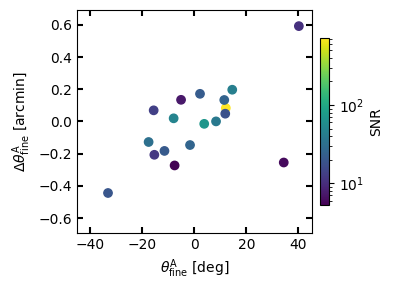

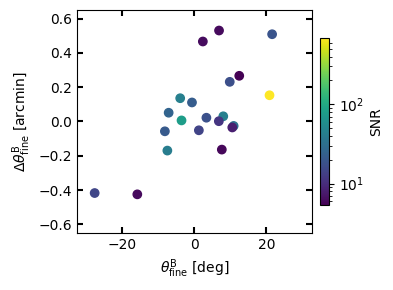

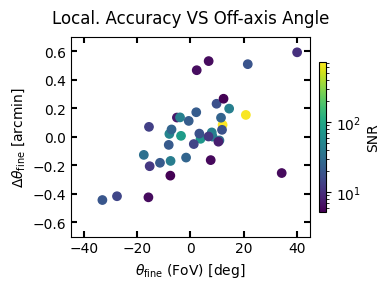

In [42]:
thetax_A, thetax_B = map(np.array, (logA.log['angle_x'], logB.log['angle_x']))


crdres_fine_A = np.array(data_camA['DthetaX'])
offaxis_fine_A = thetax_A - crdres_fine_A
snrvals_A = np.array(data_camA['SNR'])

show_OptimRes_vs_offaxis(
    offaxis=offaxis_fine_A,
    residues=crdres_fine_A,
    snrvals=snrvals_A,
    xlabel='$\\theta_{\\text{fine}}^{\\text{A}}$ [deg]',
    ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{A}}$ [arcmin]',
    # save_to=f'{OUT_RESULTS_PATH}/coordsRes_vs_offaxis_camA.pdf',
    figsize=(4.0, 3.0),
    xlims=get_symlimits(offaxis_fine_A, offset=5),
    ylims=get_symlimits(crdres_fine_A, offset=0.1),
)


crdres_fine_B = np.array(data_camB['DthetaX'])
offaxis_fine_B = thetax_B - crdres_fine_B
snrvals_B = np.array(data_camB['SNR'])

show_OptimRes_vs_offaxis(
    offaxis=offaxis_fine_B,
    residues=crdres_fine_B,
    snrvals=snrvals_B,
    xlabel='$\\theta_{\\text{fine}}^{\\text{B}}$ [deg]',
    ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{B}}$ [arcmin]',
    # save_to=f'{OUT_RESULTS_PATH}/coordsRes_vs_offaxis_camB.pdf',
    figsize=(4.0, 3.0),
    xlims=get_symlimits(offaxis_fine_B, offset=5),
    ylims=(-0.65, 0.65), #get_symlimits(crdres_fine_B, offset=0.1),
)

# all from CAM1A and CAM1B
res_cat = np.concat([crdres_fine_A, crdres_fine_B])
show_OptimRes_vs_offaxis(
    offaxis=np.concat([offaxis_fine_A, offaxis_fine_B]),
    residues=res_cat,
    snrvals=np.concat([snrvals_A, snrvals_B]),
    xlabel='$\\theta_{\\text{fine}}$ (FoV) [deg]',
    ylabel='$\\Delta\\theta_{\\text{fine}}$ [arcmin]',
    title='Local. Accuracy VS Off-axis Angle',
    save_to=f'{OUT_RESULTS_PATH}/coordsRes_vs_offaxis_cams.pdf',
    figsize=(4.0, 3.0),
    xlims=(-45.0, 45.0),  # get_symlimits(offaxis_fine_B, offset=5),
    ylims=(-0.7, 0.7), # get_symlimits(res_cat, offset=0.1),
)

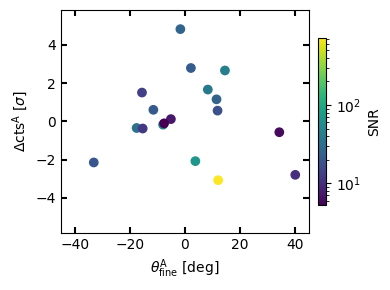

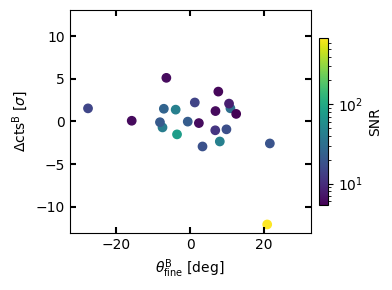

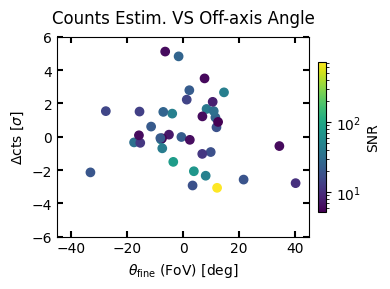

In [43]:
ctsres_A, ctsres_B = map(np.array, (data_camA['Dcts'], data_camB['Dcts']))

show_OptimRes_vs_offaxis(
    offaxis=offaxis_fine_A,
    residues=ctsres_A,
    snrvals=snrvals_A,
    xlabel='$\\theta_{\\text{fine}}^{\\text{A}}$ [deg]',
    ylabel='$\\Delta{\\text{cts}}^{\\text{A}}$ [$\\sigma$]',
    # save_to=f'{OUT_RESULTS_PATH}/ctsRes_vs_offaxis_camA.pdf',
    figsize=(4.0, 3.0),
    xlims=get_symlimits(offaxis_fine_A, offset=5),
    ylims=get_symlimits(ctsres_A, offset=1),
)

show_OptimRes_vs_offaxis(
    offaxis=offaxis_fine_B,
    residues=ctsres_B,
    snrvals=snrvals_B,
    xlabel='$\\theta_{\\text{fine}}^{\\text{B}}$ [deg]',
    ylabel='$\\Delta{\\text{cts}}^{\\text{B}}$ [$\\sigma$]',
    # save_to=f'{OUT_RESULTS_PATH}/ctsRes_vs_offaxis_camB.pdf',
    figsize=(4.0, 3.0),
    xlims=get_symlimits(offaxis_fine_B, offset=5),
    ylims=get_symlimits(ctsres_B, offset=1),
)

# all from CAM1A and CAM1B
res_cat = np.concat([ctsres_A, ctsres_B])
show_OptimRes_vs_offaxis(
    offaxis=np.concat([offaxis_fine_A, offaxis_fine_B]),
    residues=res_cat,
    snrvals=np.concat([snrvals_A, snrvals_B]),
    xlabel='$\\theta_{\\text{fine}}$ (FoV) [deg]',
    ylabel='$\\Delta{\\text{cts}}$ [$\\sigma$]',
    title='Counts Estim. VS Off-axis Angle',
    save_to=f'{OUT_RESULTS_PATH}/ctsRes_vs_offaxis_cams.pdf',
    figsize=(4.0, 3.0),
    xlims=(-45, 45),  # get_symlimits(offaxis_fine_B, offset=5),
    ylims=(-6, 6), # get_symlimits(crdres_fine_B, offset=0.1),
)

### <center>**LEM-X Unit Point-Source Location Accuracy**<center>

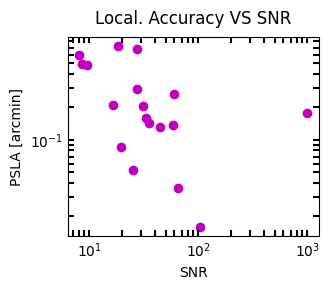

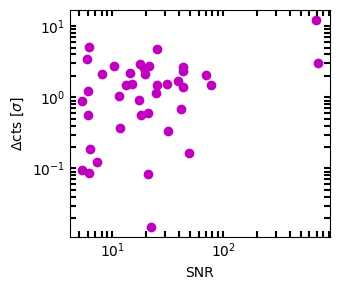

In [50]:
from typing import Optional

def show_psla_vs_snr(
    coord_res: NDArray,
    snrvals: NDArray,
    xlabel: str,
    ylabel: str,
    title: str | None = None,
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    xlims: Optional[tuple[float, float]] = (None, None),
    ylims: Optional[tuple[float, float]] = (None, None),
    **fig_kws,
    ) -> None:
    """Plots the coordinates residues vs off-axis angle."""
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.scatter(snrvals, coord_res, c='m')
    
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(xlims); ax.set_ylim(ylims)
    ax.set_title(title or '', pad=10)
    ax.set_xlabel(xlabel=xlabel); ax.set_ylabel(ylabel=ylabel)
    ax.xaxis.set_ticks_position('both'); ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return


# # single-cam A
# show_psla_vs_snr(
# #     coord_res=np.sqrt(crdres_fine_A ** 2 + np.array(data_camA['DthetaY']) ** 2),
#     coord_res=np.abs(crdres_fine_A),
#     snrvals=snrvals_A,
#     xlabel='SNR',
#     ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{A}}$ [arcmin]',
#     save_to=f'{OUT_RESULTS_PATH}/../psla_vs_snr_{'smoothed_' if 'smoothed' in RUN_ID else ''}{DATASET}_{E_min}-{E_max}keV_{ID_CAMERA_A}.pdf',
#     figsize=(4.0, 3.0),
# )

# # single-cam B
# show_psla_vs_snr(
# #     coord_res=np.sqrt(crdres_fine_B ** 2 + np.array(data_camB['DthetaY']) ** 2),
#     coord_res=np.abs(crdres_fine_B),
#     snrvals=snrvals_B,
#     xlabel='SNR',
#     ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{B}}$ [arcmin]',
#     save_to=f'{OUT_RESULTS_PATH}/../psla_vs_snr_{'smoothed_' if 'smoothed' in RUN_ID else ''}{DATASET}_{E_min}-{E_max}keV_{ID_CAMERA_B}.pdf',
#     figsize=(4.0, 3.0),
# )

# Unit module
cmn_df = unit_data.dropna()
show_psla_vs_snr(
    coord_res=np.sqrt(cmn_df['DthetaX_A'] ** 2 + cmn_df['DthetaX_B'] ** 2),
    snrvals=cmn_df['SNR'],
    # coord_res=np.concat([np.abs(crdres_fine_A), np.abs(crdres_fine_B)]),
    # snrvals=np.concat([snrvals_A, snrvals_B]),
    xlabel='SNR',
    ylabel='PSLA [arcmin]',
    title='Local. Accuracy VS SNR',
    # ylabel='$\\Delta\\theta_{\\text{fine}}$ [arcmin]',
    save_to=f'{OUT_RESULTS_PATH}/psla_vs_snr_{'smoothed_' if 'smoothed' in RUN_ID else ''}{DATASET}_{E_min}-{E_max}keV_Unit.pdf',
    figsize=(3.4, 3.0),
)

show_psla_vs_snr(
    coord_res=np.concat([np.abs(ctsres_A), np.abs(ctsres_B)]),
    snrvals=np.concat([snrvals_A, snrvals_B]),
    xlabel='SNR',
    ylabel='$\\Delta{\\text{cts}}$ [$\\sigma$]',
    # save_to=f'{OUT_RESULTS_PATH}/dcts_vs_snr_{'smoothed_' if 'smoothed' in RUN_ID else ''}{DATASET}_{E_min}-{E_max}keV_Unit.pdf',
    figsize=(3.5, 3.0),
)

<br>

<br>

<br>

### <center>**SPSF Comparison**<center>

In [37]:
SPSF_CFR: bool = False

assert SPSF_CFR, 'Aborted SPSF comparison between IROS tests...'

AssertionError: Aborted SPSF comparison between IROS tests...

In [ ]:
from bloodmoon.images import argmax
from bloodmoon.optim import model_sky

def plot_SPSF(
    camera: CodedMaskCamera,
    log: Log,
    trg_srcIDs: list[str],
    start_sky: NDArray,
    crp: tuple[int, int] = (36, 4),
    vignetting: bool = False,
    psfy: bool = False,
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Plots target sources SPSF slice along fine direction and relative residues wrt IROS sky.
    """
    def set_phase(x: NDArray) -> NDArray:
        """Centers x values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5

    start_sky_ = start_sky.copy()
    fig, axs = plt.subplots(2, len(trg_srcIDs), tight_layout=True, **fig_kws)
    axs = axs.flat
    
    for src, sx, sy, cts, thetax in zip(
        log.log['ID'], log.log['shift_x'], log.log['shift_y'], log.log['fluence'], log.log['angle_x'],
    ):
        sky_model = model_sky(camera, sx, sy, cts, vignetting, psfy)

        if src in trg_srcIDs:
            print(f'Baking {src.upper()}...')
            src_idx = trg_srcIDs.index(src)
            pos = argmax(start_sky_)
            src_psf, src_model = map(lambda x: ds.crop(x, pos, crp), (start_sky_, sky_model))
            residues = (src_psf - src_model) * 100 / src_psf.max()

            n, m = src_psf.shape
            xslice, _ = zip(
                *tuple((c[(n - 1) // 2, :], c[:, (m - 1) // 2]) for c in (src_psf, src_model, residues))
            )
            x = set_phase(xslice[0])

            axs[src_idx].stairs(xslice[0], edges=x, edgecolor='OrangeRed', label='true')
            axs[src_idx].stairs(xslice[1], edges=x, edgecolor='DodgerBlue', label='modelled')
            axs[src_idx].set_xlabel(xlabel='phase (fine axis) [px]')
            axs[src_idx].set_ylabel(ylabel='counts [ph]')
            axs[src_idx].set_title(f'{src.upper()} SkySlice | $\\theta_{{\\text{{fine}}}}$={thetax:.1f}°', fontsize='medium')

            axs[src_idx + len(trg_srcIDs)].stairs(np.zeros_like(xslice[0]), edges=x, edgecolor='OrangeRed', label='ground', linestyle='--')
            axs[src_idx + len(trg_srcIDs)].stairs(xslice[2], edges=x, edgecolor='DodgerBlue', label='residues')
            axs[src_idx + len(trg_srcIDs)].set_xlabel(xlabel='phase (fine axis) [px]')
            axs[src_idx + len(trg_srcIDs)].set_ylabel(ylabel='$\\Delta\\text{counts}$ [%]')
            axs[src_idx + len(trg_srcIDs)].set_title('Residues', fontsize='medium')

        start_sky_ -= sky_model

    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)
        ax.legend(loc='best')

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    
    return

In [ ]:
def print_src_angle(log: Log) -> None:
    for src, snrlvl, thetax in zip(log.log['ID'], log.log['snr'], log.log['angle_x']):
        print(f'{src.upper()} (SNR = {float(snrlvl):.1f}) @ {float(thetax):.1f}°')
    return

print_src_angle(logA)

S17 (SNR = 675.0) @ -28.1°
S29 (SNR = 164.2) @ 25.1°
S11 (SNR = 149.6) @ -22.5°
S25 (SNR = 120.3) @ 6.2°
S13 (SNR = 64.5) @ -15.5°
S12 (SNR = 73.2) @ -19.2°
S32 (SNR = 79.7) @ -34.2°
S24 (SNR = 59.9) @ -20.0°
S22 (SNR = 63.7) @ -30.6°
S19 (SNR = 43.7) @ 15.4°
S2 (SNR = 53.7) @ -27.3°
S0 (SNR = 42.7) @ -17.3°
S10 (SNR = 51.7) @ 2.5°
S27 (SNR = 35.7) @ -13.6°
S26 (SNR = 35.8) @ -17.8°
S9 (SNR = 36.4) @ 20.8°
S31 (SNR = 53.5) @ 27.5°
S33 (SNR = 47.3) @ 23.1°
S5 (SNR = 28.0) @ 22.8°
S8 (SNR = 32.0) @ 32.6°
S20 (SNR = 22.7) @ -6.3°
S6 (SNR = 26.2) @ -26.1°
S35 (SNR = 33.1) @ 35.7°
S18 (SNR = 28.5) @ -29.9°
S23 (SNR = 13.3) @ -1.2°


Baking S17...
Baking S29...
Baking S13...
Baking S19...
Baking S10...


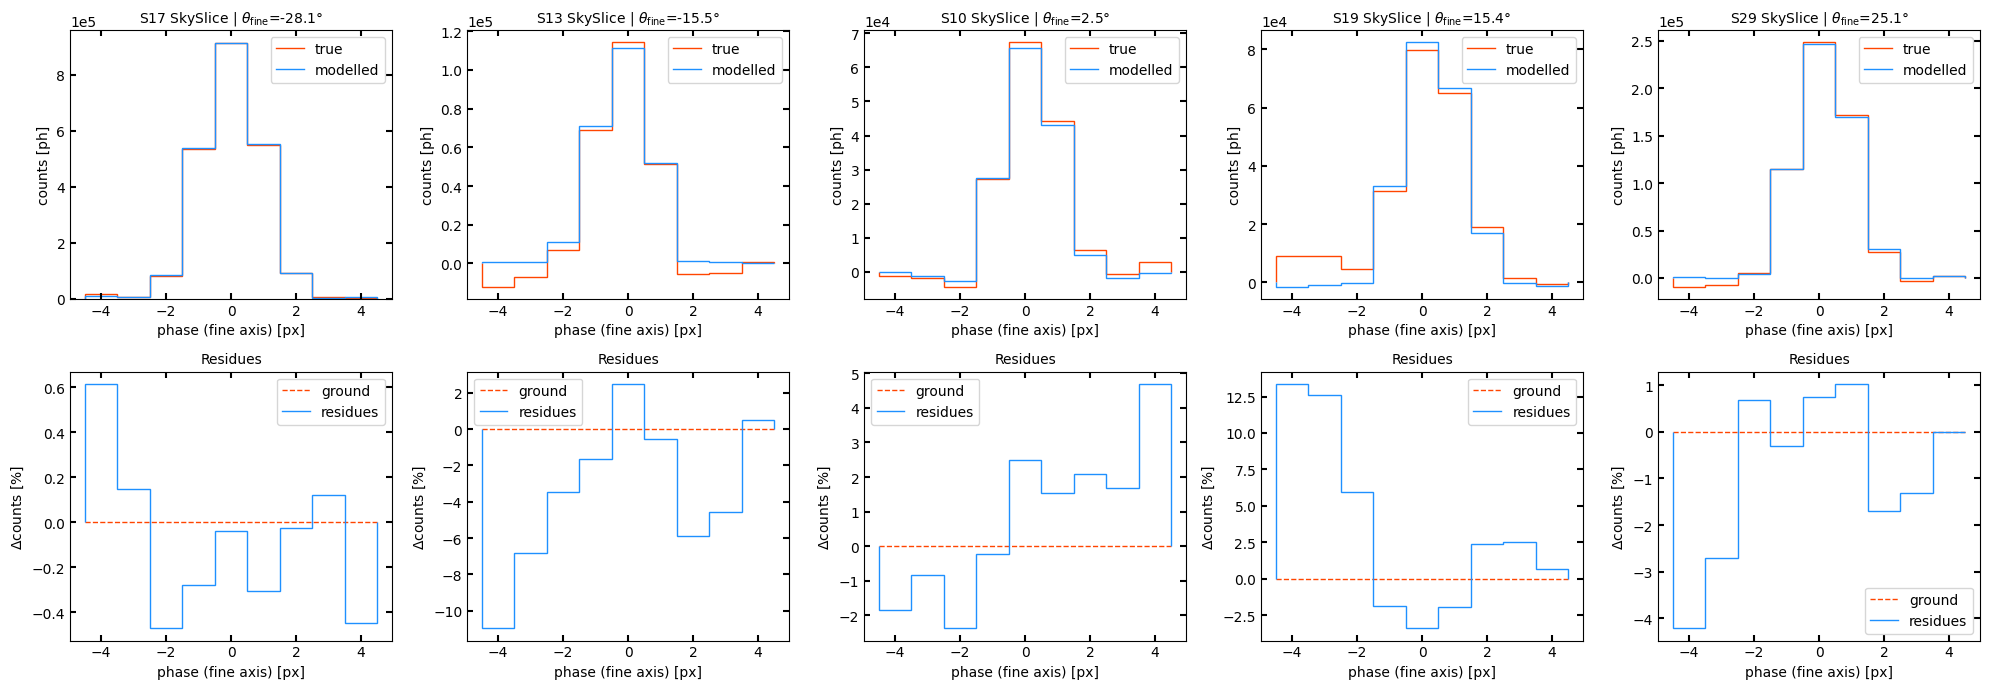

In [ ]:
bncmrkID = f'SPSF_bncmrk_{E_min}-{E_max}keV_1ks_{DATASET}_infdense_NewSGNorm'

trg_srcIDs: list[str] = [
    's17', 's13', 's10', 's19', 's29',
]
plot_SPSF(
    camera=wfm,
    log=logA,
    trg_srcIDs=trg_srcIDs,
    start_sky=skyA,
    vignetting=True,
    figsize=(4.0 * len(trg_srcIDs), 7.0),
    save_to=f'{OUT_RESULTS_PATH}/{bncmrkID}.svg',
)

<br>

<br>

<br>

### <center>**Runs Comparison**<center>

In [ ]:
RUN_CFR: bool = False

assert RUN_CFR, 'Aborted running IROS reconstructions comparison...'

AssertionError: Aborted running IROS reconstructions comparison...

In [ ]:
from typing import Optional

def cfr_runs(
    camera_ID: str,
    fst_runID: str,
    snd_runID: str,
    camera: CodedMaskCamera,
    fst_dataset: str = 'reconstructed',
    fst_sdl_kws: Optional[dict[str, Any]] = None,
    snd_dataset: str = 'reconstructed',
    snd_sdl_kws: Optional[dict[str, Any]] = None,
) -> pd.DataFrame:
    """
    Gathers data from given IROS runs and extracts coords and cts residues.
    """
    def gather(runID: str, dataset: str, kws: Optional[dict[str, Any]]) -> tuple[DataLoader, CatalogueLoader, Log]:
        kws_ = kws or {}
        _, datapath, savepath = config_dirpaths(
            mask=MASK_FITS,
            skyfield=SKYFIELD,
            simul=DATA_FITS,
            runID=runID,
        )
        filepaths = simulation_files(datapath)
        sdl = ds.get_data(filepaths[camera_ID][dataset], **kws_)
        cat = ds.get_catalogue(filepaths[camera_ID]['sources'])
        logA, logB = ds.load_database(f"{savepath}/IROS_sources_db.fits")
        log = logA if (logA.name == camera_ID.upper()) else logB
        return sdl, cat, log

    sdl_fst, cat_fst, log_fst = gather(fst_runID, fst_dataset, fst_sdl_kws)
    sdl_snd, cat_snd, log_snd = gather(snd_runID, snd_dataset, snd_sdl_kws)
    (_, varmap_fst), (_, varmap_snd) = map(lambda sdl: get_sky_varmap(camera, sdl), (sdl_fst, sdl_snd))

    data_fst = gather_cam_data(log_fst, cat_fst, sdl_fst, camera, varmap_fst)
    data_snd = gather_cam_data(log_snd, cat_snd, sdl_snd, camera, varmap_snd)

    # NOTE: data relative to not associated sources is DROPPED
    _sfxs = ('_fst', '_snd')
    _col2drop = ('True_cts', 'IROS_cts', 'SNR')
    df = pd.merge(data_fst.dropna(), data_snd.dropna(), on='Source', how='outer', suffixes=_sfxs)
    df = df.drop(columns=[f'{col}{sfx}' for sfx in _sfxs for col in _col2drop])
    return df


def show_Dcts_vs_UPX(
    fst_hist: NDArray,
    snd_hist: NDArray,
    bins: NDArray,
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    xlabel: str | None = None,
    fst_lbl: str | None = None,
    snd_lbl: str | None = None,
    **fig_kws,
) -> None:
    """Plots the residual counts distribution."""
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.stairs(fst_hist, edges=bins, fill=True, facecolor='OrangeRed', label=fst_lbl, alpha=0.6)
    ax.stairs(snd_hist, edges=bins, fill=True, facecolor='DodgerBlue', label=snd_lbl, alpha=0.6)
    ax.set_xlabel(xlabel=xlabel); ax.set_ylabel(ylabel='density')
    ax.xaxis.set_ticks_position('both'); ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)
    ax.legend(loc='best')
    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return

In [ ]:
cfr_data_A = cfr_runs(
    camera=wfm,
    camera_ID=ID_CAMERA_A,
    fst_runID='GC_smoothed_rec_1ks_2-50keV_mask25',
    fst_sdl_kws=dict(E_min=2.0, E_max=50.0),
    snd_runID='GC_smoothed_rec_1ks_detected_2-6keV_mask25',
    snd_dataset='detected',
    snd_sdl_kws=dict(E_min=2.0, E_max=6.0),
)
cfr_data_B = cfr_runs(
    camera=wfm,
    camera_ID=ID_CAMERA_B,
    fst_runID='GC_smoothed_rec_1ks_2-50keV_mask25',
    fst_sdl_kws=dict(E_min=2.0, E_max=50.0),
    snd_runID='GC_smoothed_rec_1ks_detected_2-6keV_mask25',
    snd_dataset='detected',
    snd_sdl_kws=dict(E_min=2.0, E_max=6.0),
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


Analysing SERX1: 100%|██████████| 17/17 [00:00<00:00, 17.31it/s]       


# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


Analysing LEMX-CAM1BS1: 100%|██████████| 21/21 [00:01<00:00, 18.96it/s]  


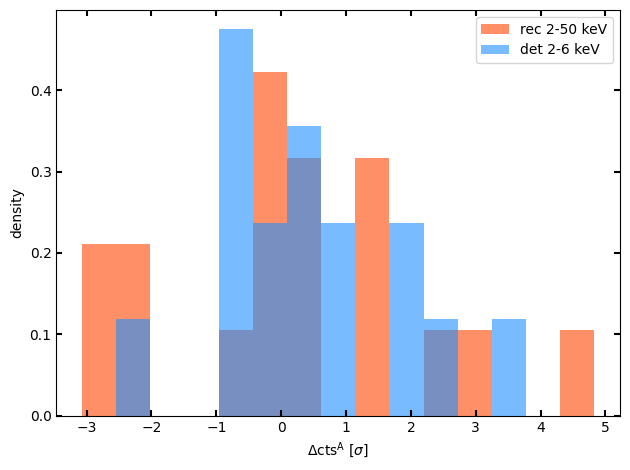

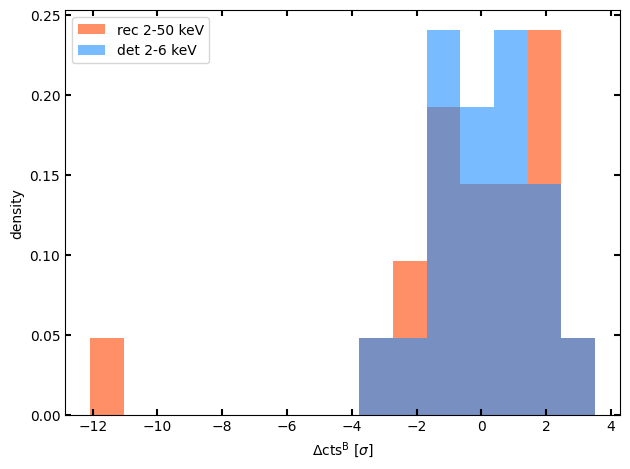

In [ ]:
num_bins = 15
density = True

hist_A_fst, bins_A = np.histogram(np.array(cfr_data_A['Dcts_fst']), bins=num_bins, density=density)
hist_A_snd, _ = np.histogram(np.array(cfr_data_A['Dcts_snd']), bins=bins_A, density=density)

show_Dcts_vs_UPX(
    fst_hist=hist_A_fst,
    snd_hist=hist_A_snd,
    bins=bins_A,
    xlabel='$\\Delta{\\text{cts}}^{\\text{A}}$ [$\\sigma$]',
    fst_lbl='rec 2-50 keV',
    snd_lbl='det 2-6 keV',
)


hist_B_fst, bins_B = np.histogram(np.array(cfr_data_B.dropna()['Dcts_fst']), bins=num_bins, density=density)
hist_B_snd, _ = np.histogram(np.array(cfr_data_B.dropna()['Dcts_snd']), bins=bins_B, density=density)

show_Dcts_vs_UPX(
    fst_hist=hist_B_fst,
    snd_hist=hist_B_snd,
    bins=bins_B,
    xlabel='$\\Delta{\\text{cts}}^{\\text{B}}$ [$\\sigma$]',
    fst_lbl='rec 2-50 keV',
    snd_lbl='det 2-6 keV',
)

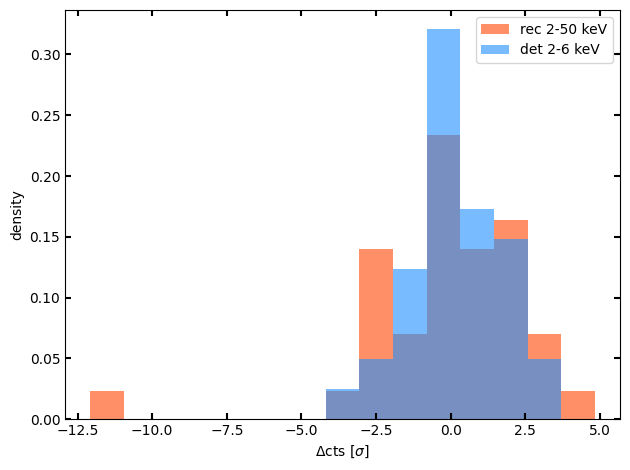

In [ ]:
num_bins = 15
density = True

hist_fst, bins = np.histogram(
    np.concat(list(map(np.array, (cfr_data_A['Dcts_fst'], cfr_data_B.dropna()['Dcts_fst'])))), bins=num_bins, density=density,
)
hist_snd, _ = np.histogram(
    np.concat(list(map(np.array, (cfr_data_A['Dcts_snd'], cfr_data_B.dropna()['Dcts_snd'])))), bins=bins, density=density,
)

show_Dcts_vs_UPX(
    fst_hist=hist_fst,
    snd_hist=hist_snd,
    bins=bins,
    xlabel='$\\Delta{\\text{cts}}$ [$\\sigma$]',
    fst_lbl='rec 2-50 keV',
    snd_lbl='det 2-6 keV',
)

In [ ]:
# ds.plot(
#     dmaps=(
#         ds.map4plot(
#             arrs=(cfr_data_A['DthetaX_fst'] - cfr_data_A['DthetaX_snd'], cfr_data_B['DthetaX_fst'] - cfr_data_B['DthetaX_snd']),
#             title='Coords Res Diff - Fine Axis',
#             labels=(f'{ID_CAMERA_A.upper()}', f'{ID_CAMERA_B.upper()}'),
#             style='scatter',
#         ),
#         ds.map4plot(
#             arrs=(cfr_data_A['Dcts_fst'] - cfr_data_A['Dcts_snd'], cfr_data_B['Dcts_fst'] - cfr_data_B['Dcts_snd']),
#             title='Cts Res Diff - Fine Axis',
#             labels=(f'{ID_CAMERA_A.upper()}', f'{ID_CAMERA_B.upper()}'),
#             style='scatter',
#         ),
#     ),
#     ncols=2,
# )